In [ ]:
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import gspread
from google.colab import auth
from google.auth import default

# 授权
auth.authenticate_user()
creds, _ = default()
gc = gspread.authorize(creds)

In [ ]:
spreadsheet = gc.open("BFS Performance")
# 指定sheet名称
worksheet = spreadsheet.worksheet("Summary")

# 获取所有数据（返回的是嵌套list）
data = worksheet.get_all_values()

In [ ]:
Algorithm_name = [data[0][0], data[11][0], data[22][0]]
print(Algorithm_name)

['Push Pull', 'Push', 'LB Push']


In [ ]:
graph_name = [data[i][data[0].index('Edges')-1].replace(" ", "") for i in range(1, 9)]
graph_edges = [int(data[i][data[0].index('Edges')].replace(",", "")) for i in range(1, 9)]
print(graph_name)
print(graph_edges)

['wiki-topcats', 'RMAT', 'ErdosRenyi', 'ForestFire', 'Twitter', 'soc-liveJournal', 'orkut', 'protein']
[50892080, 8268666550, 9395215892, 1185662755, 2405026390, 86220856, 234370168, 1309240502]


In [ ]:
simTicks = []
nodes = [1, 2, 4, 8, 16, 32, 64, 128, 256]

tmp0 = []
for i in range(1, 9):
    tmp0.append([float(data[i][j]) for j in range(data[0].index('1') , data[0].index('256')+1)])
simTicks.append(tmp0)

tmp0 = []
for i in range(12, 20):
    tmp0.append([float(data[i][j]) for j in range(data[0].index('1') , data[0].index('256')+1)])
simTicks.append(tmp0)

tmp0 = [[]]
for i in range(24, 31):
    tmp0.append([float(data[i][j]) for j in range(data[0].index('1') , data[0].index('256')+1)])
simTicks.append(tmp0)

print(simTicks[0])
print(simTicks[1])
print(simTicks[2])

[[1226100.0, 873300.0, 637200.0, 485600.0, 424000.0, 410300.0, 445500.0, 484100.0, 605600.0], [49125700.0, 31025000.0, 18830500.0, 11125600.0, 5757100.0, 3020500.0, 1645900.0, 1189000.0, 907100.0], [265077200.0, 144581000.0, 85517000.0, 49042900.0, 25395300.0, 12319800.0, 6700500.0, 3847800.0, 2328500.0], [421075400.0, 209682100.0, 78641400.0, 26970100.0, 22863300.0, 11584600.0, 8463800.0, 5445200.0, 3621800.0], [28819400.0, 20085300.0, 12528500.0, 7232000.0, 5351600.0, 4612600.0, 3611500.0, 1803100.0, 1631100.0], [5260600.0, 5087900.0, 3629400.0, 2608900.0, 1569200.0, 1008000.0, 800800.0, 807600.0, 958900.0], [1715700.0, 1321600.0, 892900.0, 615100.0, 478900.0, 408100.0, 394100.0, 442300.0, 559900.0], [5452800.0, 3258500.0, 892900.0, 478900.0, 408100.0, 394100.0, 576400.0, 582000.0, 684600.0]]
[[2132600.0, 1295600.0, 888900.0, 708000.0, 611400.0, 553200.0, 616800.0, 584500.0, 583500.0], [393816700.0, 170918800.0, 101089500.0, 53245200.0, 22459900.0, 12575500.0, 6598400.0, 3489800.0, 2

In [ ]:
speedup = []
for i in range(len(simTicks)):
    tmp1 = []
    for j in range(len(simTicks[i])):
        tmp = []
        for k in range(len(simTicks[i][j])):
            tmp.append(simTicks[i][j][0]/simTicks[i][j][k])
        tmp1.append(tmp)
    speedup.append(tmp1)
print(speedup[0])
print(speedup[1])
print(speedup[2])

[[1.0, 1.4039848849192718, 1.9241996233521657, 2.5249176276771004, 2.891745283018868, 2.988301242992932, 2.752188552188552, 2.5327411691799213, 2.0246036988110965], [1.0, 1.583423045930701, 2.6088367276492925, 4.415555116128568, 8.533063521564676, 16.264095348452244, 29.847317577009537, 41.31682085786375, 54.15687355308125], [1.0, 1.8334165623422165, 3.099701813674474, 5.405006637046341, 10.438041684878698, 21.51635578499651, 39.560808894858596, 68.89058682883726, 113.84032639038007], [1.0, 2.0081609255153396, 5.354373141882011, 15.612674776882548, 18.417087647015084, 36.347858363689724, 49.75015950282379, 77.32964813046353, 116.26136175382406], [1.0, 1.434850363200948, 2.300307299357465, 3.984983407079646, 5.385193213244637, 6.247972943676018, 7.97989754949467, 15.98325106760579, 17.668689841211453], [1.0, 1.0339432771870516, 1.4494406789000938, 2.016405381578443, 3.3524088707621718, 5.218849206349207, 6.569180819180819, 6.513868251609708, 5.486077797476275], [1.0, 1.2981991525423728,

In [ ]:
GEPS = []
for i in range(len(simTicks)):
    tmp1 = []
    for j in range(len(simTicks[i])):
        tmp = []
        for k in range(len(simTicks[i][j])):
            tmp.append(graph_edges[j]/1e9 / (simTicks[i][j][k]/2e9))
        tmp1.append(tmp)
    GEPS.append(tmp1)
print(GEPS[0])
print(GEPS[1])
print(GEPS[2])

[[83.01456651170378, 116.55119661055765, 159.73659761456372, 209.60494233937396, 240.05698113207546, 248.07253229344383, 228.47173961840627, 210.25441024581698, 168.07159841479526], [336.6330271120819, 533.032493150685, 878.2206048697592, 1486.4216851226004, 2872.511003803999, 5475.031650389009, 10047.592867124371, 13908.60647603028, 18230.99228309999], [70.88663900177005, 129.96473799461893, 219.72744347907434, 383.1427542824751, 739.9176928014239, 1525.222145164694, 2804.3327787478547, 4883.422159155881, 8069.758120678549], [5.631593557828361, 11.309146131214824, 30.153653292031933, 87.9242386939611, 103.71755214689044, 204.69636500181275, 280.17267775703584, 435.48914824065236, 654.7367358771882], [166.90329361471788, 239.4812514625124, 383.9288645887377, 665.106855641593, 898.8064840421557, 1042.8072627151716, 1331.8711837186765, 2667.6572458543624, 2948.962528355098], [32.779856290157014, 33.89251203836553, 47.51245715545269, 66.09747863084058, 109.89148100943156, 171.073126984127

(np.float64(0.5), np.float64(512.0))


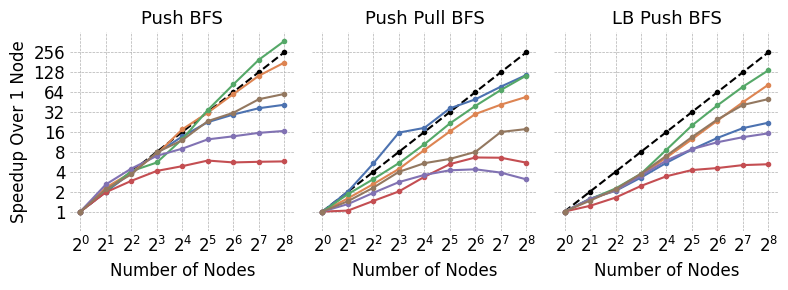

In [ ]:
choose_graph = ['ForestFire','RMAT', 'ErdosRenyi', 'soc-liveJournal', 'orkut', 'Twitter']
graph_label = ['FF', 'RMAT', 'ER', 'LJ', 'Orkut', 'Twitter']
Algorithm_order = ['Push', 'Push Pull', 'LB Push']
Algorithm_label = ['Push BFS', 'Push Pull BFS', 'LB Push BFS']
nodes = [1, 2, 4, 8, 16, 32, 64, 128, 256]
linear_speedup = [1, 2, 4, 8, 16, 32, 64, 128, 256]
linear_speedup_name = ['1', '2', '4', '8', '16', '32', '64', '128', '256']

# 颜色方案（Seaborn 深色调色盘）
colors = sns.color_palette("deep", len(choose_graph))

fig, axes = plt.subplots(1, 3, figsize=(8, 3), sharey=True)
for i,ax in enumerate(axes):
    ax.set_ylim(0.5, 512)
    ax.set_xscale('log', base=2)
    ax.set_yscale('log', base=2)
    ax.set_xticks(nodes)
    ax.set_xticklabels(nodes)
    ax.set_yticks(linear_speedup)
    ax.set_yticklabels(linear_speedup_name, fontsize=12)
    ax.set_xlabel(f'Number of Nodes', fontsize=12)
    ax.set_title(f"{Algorithm_label[i]}", fontsize=13)
    ax.grid(True, linestyle="--", linewidth=0.5)
    ax.spines[:].set_visible(False)
    ax.set_xticklabels([r"$2^{" + f"{round(np.log2(node))}" + r"}$" for node in nodes], fontsize=12)
    ax.tick_params(length=0)
    if i == 0:
        ax.set_ylabel('Speedup Over 1 Node', fontsize=12)
        # ax.set_yticks(nodes)
        # ax.set_yticklabels(linear_speedup_name)
        print(ax.get_ylim())
        ax.plot(nodes, linear_speedup, marker=".", label="Linear", linestyle="--", color="black")
        for graph_idx in range(len(choose_graph)):
            ax.plot(nodes, speedup[Algorithm_name.index(Algorithm_order[i])][graph_name.index(choose_graph[graph_idx])], marker=".", label=graph_label[graph_idx], linestyle="-", color=colors[graph_idx])
    else:
        ax.plot(nodes, linear_speedup, marker=".", linestyle="--", color="black")
        for graph_idx in range(len(choose_graph)):
            ax.plot(nodes, speedup[Algorithm_name.index(Algorithm_order[i])][graph_name.index(choose_graph[graph_idx])], marker=".", linestyle="-", color=colors[graph_idx])

# fig.legend(loc='upper center', bbox_to_anchor=(0.5, 0.98), ncol=len(choose_graph)+1, columnspacing=.5)
# fig.suptitle("Different BFS Speedup over one machine on different nodes", y=1.03)
# 调整布局
plt.tight_layout()  # 给legend和总标题留出空间)
plt.savefig("BFS_speedupv2.pdf", format="pdf", bbox_inches="tight")
plt.show()

FF
[32, 64, 128, 256]
[204.69636500181275, 280.17267775703584, 435.48914824065236, 654.7367358771882]
RMAT
[32, 64, 128, 256]
[5475.031650389009, 10047.592867124371, 13908.60647603028, 18230.99228309999]
ER
[32, 64, 128, 256]
[1525.222145164694, 2804.3327787478547, 4883.422159155881, 8069.758120678549]
(np.float64(3.759433034294359), np.float64(27309.846393791508))


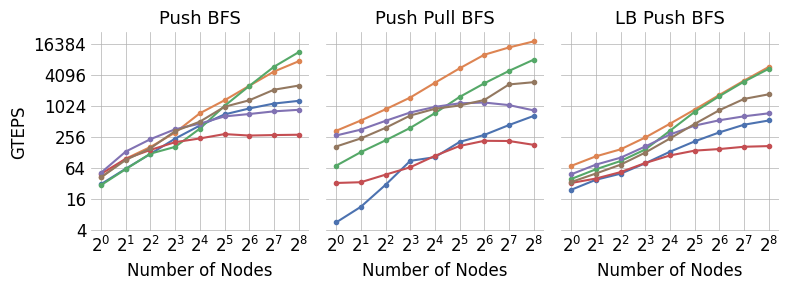

In [ ]:
choose_graph = ['ForestFire','RMAT', 'ErdosRenyi', 'soc-liveJournal', 'orkut', 'Twitter']
graph_label = ['FF', 'RMAT', 'ER', 'LJ', 'Orkut', 'Twitter']
Algorithm_order = ['Push', 'Push Pull', 'LB Push']
Algorithm_label = ['Push BFS', 'Push Pull BFS', 'LB Push BFS']
nodes = [1, 2, 4, 8, 16, 32, 64, 128, 256]
y_label = [4, 16, 64, 256, 1024, 4096, 16384]
y_label_name = ['4', '16', '64', '256', '1024', '4096', '16384']

# 颜色方案（Seaborn 深色调色盘）
colors = sns.color_palette("deep", len(choose_graph))

fig, axes = plt.subplots(1, 3, figsize=(8, 3), sharey=True)
for i,ax in enumerate(axes):
    # ax.set_ylim(0.5, 512)
    ax.set_xscale('log', base=2)
    ax.set_yscale('log', base=2)
    ax.set_xticks(nodes)
    ax.set_xticklabels(nodes)
    ax.set_yticks(y_label)
    ax.set_yticklabels(y_label_name, fontsize=12)
    ax.set_xlabel(f'Number of Nodes', fontsize=12)
    ax.set_title(f"{Algorithm_label[i]}", fontsize=13)
    ax.grid(True, linestyle="-", linewidth=0.5)
    ax.spines[:].set_visible(False)
    ax.set_xticklabels([r"$2^{" + f"{round(np.log2(node))}" + r"}$" for node in nodes], fontsize=12)
    ax.tick_params(length=0)
    if i == 0:
        ax.set_ylabel('GTEPS', fontsize=12)
        # ax.set_yticks(nodes)
        # ax.set_yticklabels(linear_speedup_name)
        # ax.plot(nodes, linear_speedup, marker=".", label="Linear", linestyle="-", color="black")
        for graph_idx in range(len(choose_graph)):
            ax.plot(nodes, GEPS[Algorithm_name.index(Algorithm_order[i])][graph_name.index(choose_graph[graph_idx])], marker=".", label=graph_label[graph_idx], linestyle="-", color=colors[graph_idx])
            if graph_label[graph_idx] in ["ER","RMAT","FF"]:
                print(graph_label[graph_idx])
                print(nodes[5:])
                print(GEPS[i][graph_name.index(choose_graph[graph_idx])][5:])
    else:
        # ax.plot(nodes, linear_speedup, marker=".", linestyle="-", color="black")
        for graph_idx in range(len(choose_graph)):
            ax.plot(nodes, GEPS[Algorithm_name.index(Algorithm_order[i])][graph_name.index(choose_graph[graph_idx])], marker=".", linestyle="-", color=colors[graph_idx])


print(ax.get_ylim())
# fig.legend(loc='upper center', bbox_to_anchor=(0.5, 0.98), ncol=len(choose_graph)+1, columnspacing=.5)
# fig.suptitle("Different BFS Performance over one machine on different nodes", y=1.03)
# 调整布局
plt.tight_layout()  # 给legend和总标题留出空间)
plt.savefig("BFS_GEPSv2.pdf", format="pdf", bbox_inches="tight")
plt.show()